**GOAL** - THIS IS A MOVIE RECOMMENDATION MODEL WHERE THE MODEL PREDICTS TOP 5

---

SIMIALAR MOVIES WHICH USER MAY LIKE TO WATCH SIMILAR TO ITS ENTERED MOVIE CHOICE.  

the dataset conatins details of 5000 movies taken from kaggle. we have used vectorization technique to find the similarity between movies and used some scikit learn libraries like countvectorization for converting string into vectors, nltk for stemming words , cosine_similarity to find distance between vectors . we hav used random forest and accuracy and roc-auc and confusion matrix for regression metric

**Difficulty**- main difficulty was how to decide the similarity criteria between two movies because there are lakhs of words in our feature 'tags' so answer to this was vectoriztion and cosine distance and also we took help of online documentation.

**LEARNING** - most importantly we learned about how vectorization actually works and best way to deal when we are dealing with categorical columns. we also learned about stemming methos then we learned the workflow of any ml project from preprocessing to final prediction. our data was actally very clean so no need to perform any hard EDA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv


In [ ]:
import pandas as pd
import numpy as np

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

credits.columns = ['id','title','cast','crew']
df = movies.merge(credits, on='id')

df.shape


(4803, 23)

In [ ]:
df = df[['id','title_x','overview','genres','keywords','cast','crew','vote_average','vote_count','popularity']]
df.rename(columns={'title_x':'title'}, inplace=True)

df.head()


,id,title,overview,genres,keywords,cast,crew,vote_average,vote_count,popularity
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,150.437577
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,139.082615
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,107.376788
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,112.312950
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,43.926995


In [ ]:
import ast

def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

df['genres'] = df['genres'].apply(convert)
df['keywords'] = df['keywords'].apply(convert)


In [ ]:
# GETTING ACTORS NAME ONLY
def convert_cast(text):
    L = []
    counter = 0
    for i in ast.literal_eval(text):
        if counter < 3:
            L.append(i['name'])
        counter += 1
    return L

df['cast'] = df['cast'].apply(convert_cast)


In [ ]:
# GETTING DIRECTOR NAME ONLY
def fetch_director(text):
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            return i['name']
    return ''

df['crew'] = df['crew'].apply(fetch_director)


In [ ]:
# CREATING NEW FEATURE TAG TO SUMMARIZE ALL INFO
df['overview'] = df['overview'].fillna('')

df['tags'] = (
    df['overview'].apply(lambda x: x.split()) +
    df['genres'] +
    df['keywords'] +
    df['cast'] +
    df['crew'].apply(lambda x: x.split())
)

df['tags'] = df['tags'].apply(lambda x: " ".join(x).lower())

df = df[['id','title','tags','vote_average','vote_count','popularity']]


In [ ]:
df.head()

,id,title,tags,vote_average,vote_count,popularity
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di...",7.2,11800,150.437577
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha...",6.9,4500,139.082615
2,206647,Spectre,a cryptic message from bond’s past sends him o...,6.3,4466,107.376788
3,49026,The Dark Knight Rises,following the death of district attorney harve...,7.6,9106,112.312950
4,49529,John Carter,"john carter is a war-weary, former military ca...",6.1,2124,43.926995


In [ ]:
# CONVERTING STRINGS TO VECTORS SO THAT ML MODEL CAN UNDERSTAND
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors = tfidf.fit_transform(df['tags']).toarray()


In [ ]:
feature_names = tfidf.get_feature_names_out()

importance = np.sum(vectors, axis=0) #sums impoetance of each word across all movie
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

imp_df.head(10)


,feature,importance
1336,drama,121.784697
909,comedy,115.178419
1609,family,90.137794
4518,thriller,86.037609
65,action,82.705476
3828,romance,77.606019
2641,life,76.350316
3107,new,73.698630
1046,crime,69.997196
93,adventure,67.457574


In [ ]:
# FINDING DISTANCES BETWEEN TEO VECTORS (MOVIES)
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)


In [ ]:
#RECOMENDDING MOVIES HERE
def recommend(movie):
    if movie not in df['title'].values:
        return "Movie not found"

    index = df[df['title'] == movie].index[0]
    distances = list(enumerate(similarity[index]))
    distances = sorted(distances, key=lambda x: x[1], reverse=True)[1:6]

    recommendations = []
    for i in distances:
        recommendations.append(df.iloc[i[0]].title)

    return recommendations


In [ ]:
recommend("Avatar")


['Aliens', 'Alien', 'Moonraker', 'Alien³', 'Silent Running']

In [ ]:
df['liked'] = df['vote_average'].apply(lambda x: 1 if x >= 7 else 0)

X = vectors
y = df['liked']



In [ ]:
y.value_counts()

,count
liked,
0,3815
1,988


In [ ]:
# TRAINING OUR DATA BASED ON THE USER LIKE OR DISLIKE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred)) #0.75-0.90 considerd good

print("ROC AUC  :", roc_auc_score(y_test, y_prob))


Accuracy : 0.7929240374609782
ROC AUC  : 0.7153348690045938


confusion matrix

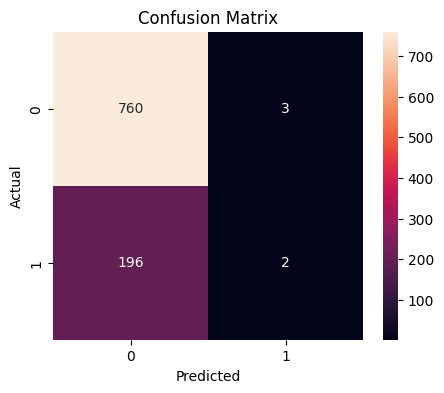

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


roc-auc curve

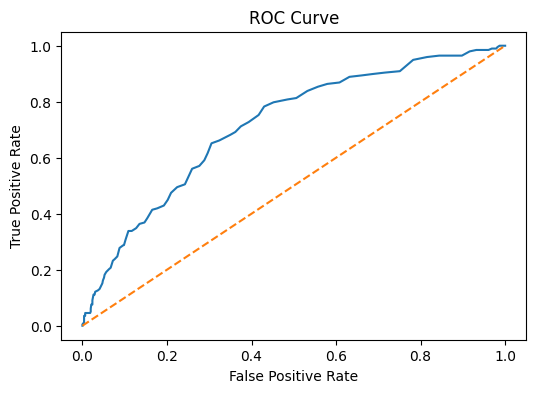

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
